# Домашнее задание 3. Анализ данных

Задание выполнил(а):

    Шульц Филипп

# Часть I

Каждое задание в этой части оценивается в 0,15 баллов. Всего за выполнение этой части можно получить 2,55 балла.

In [2]:
import pandas as pd
import seaborn as sns
from scipy.stats import norm

In [3]:
DIABETS = 'https://raw.githubusercontent.com/evgpat/datasets/main/pima_indians_diabetes.csv'
BABIES = 'https://raw.githubusercontent.com/evgpat/datasets/main/babies_all.txt'

Будем работать с датасетом Pima Indian Diabetes - это набор данных из Национального института диабета, болезней органов пищеварения и почек. Целью набора данных является диагностическое прогнозирование наличия диабета у пациента. Несколько ограничений были наложены на выбор этих экземпляров из большой базы данных. В частности, все пациенты здесь - женщины в возрасте от 21 года, индийского происхождения.

In [4]:
data = pd.read_csv(DIABETS)
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,NaN,NaN,NaN,0.232,54,1


Описание данных:

- __Pregnancies__ - данная единица отображает количество беременностей, единицы измерения - целые числа от 0 до N. Тип переменной - количественная, дискретная.
- __Glucose__ - данная единица отображает уровень глюкозы в крови, единицы измерения - целые числа. Тип переменной - количественная, дискретная.
- __BloodPressure__ - данная единица отображает артериальное давление, единицы измерения - миллиметры р/с, целые числа. Тип переменной - количественная, дискретная.
- __SkinThickness__ - данная единица отображает обхват трицепса в миллиметрах, целые числа. Тип переменной - количественная, дискретная.
- __Insulin__ - данная единица отображает уровень инсулина в крови, целые числа. Тип переменной - количественная, дискретная.
- __BMI__ - данная единица отображает индекс массы тела. Тип переменной - количественная, непрерывная.
- __DiabetesPedigreeFunction__ - данная единица отображает риск наследственного диабета в зависимости наличия диабета у родственников. Выражается десятичной дробью от 0 до 1. Тип переменной - количественная, непрерывная.
- __Age__ - данная единица отражает возраст в целых числах. Тип переменной - количественная, дискретная.
- __Class__ - данная единица отражает наличие диабета у субъекта, выражена 0(здоров) или 1(болен). Тип переменной - категориальная, бинарная.

## Задание 1

Как вы видите, в данных много пропусков (NaN). Любым способом посчитайте количество пропусков в каждом из столбцов.

Для тех переменных, в которых есть пропуски, выведите количество пропущенных значений в следующем формате:

**"В переменной {название переменной} {количество} пропущенных значений"**

In [5]:
for k, v in dict(data.isna().sum()).items():
  print(f"В переменной {k} {v} пропущенных значений")


В переменной Pregnancies 0 пропущенных значений
В переменной Glucose 5 пропущенных значений
В переменной BloodPressure 35 пропущенных значений
В переменной SkinThickness 227 пропущенных значений
В переменной Insulin 374 пропущенных значений
В переменной BMI 11 пропущенных значений
В переменной DiabetesPedigreeFunction 0 пропущенных значений
В переменной Age 0 пропущенных значений
В переменной Class 0 пропущенных значений


## Задание 2

Замените все пропуски дискретных признаков соответствующими медианами, непрерывных признаков - средними значениями.

In [6]:
discrete_variables = ('Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'Age')
continuous_variables = ('BMI', 'DiabetesPedigreeFunction')

for variable in discrete_variables:
  median = data[variable].median()
  data[variable] = data[variable].fillna(median)

for variable in continuous_variables:
    mean = data[variable].mean()
    data[variable] = data[variable].fillna(mean)

data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


## Задание 3

Выведите основные статистики (минимум, максимум, среднее, дисперсию, квантили) для всех столбцов.

In [7]:
for column in data.columns:

  print(f"column {column}: min[{data[column].min()}], max[{data[column].max()}]"
        f", mean[{data[column].mean()}], variance[{data[column].var()}], "
        f"quantile[{data[column].quantile()}]")

column Pregnancies: min[0], max[17], mean[3.8450520833333335], variance[11.35405632062142], quantile[3.0]
column Glucose: min[44.0], max[199.0], mean[121.65625], variance[926.4892438070405], quantile[117.0]
column BloodPressure: min[24.0], max[122.0], mean[72.38671875], variance[146.32874124022163], quantile[72.0]
column SkinThickness: min[7.0], max[99.0], mean[29.108072916666668], variance[77.28556707681494], quantile[29.0]
column Insulin: min[14.0], max[846.0], mean[140.671875], variance[7462.033001955671], quantile[125.0]
column BMI: min[18.2], max[67.1], mean[32.457463672391015], variance[47.26770577607697], quantile[32.4]
column DiabetesPedigreeFunction: min[0.078], max[2.42], mean[0.47187630208333325], variance[0.10977863787313938], quantile[0.3725]
column Age: min[21], max[81], mean[33.240885416666664], variance[138.30304589037365], quantile[29.0]
column Class: min[0], max[1], mean[0.3489583333333333], variance[0.22748261625380098], quantile[0.0]


## Задание 4

У скольких женщин строго старше 50 лет обнаружен диабет?

In [8]:
data[(data.Age > 50) & (data.Class == 1)].shape[0]

38

## Задание 5

Найдите трех женщин с наибольшими числом беременностей.

In [9]:
data.sort_values(by='Pregnancies', ascending=False)[0:3]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
159,17,163.0,72.0,41.0,114.0,40.9,0.817,47,1
88,15,136.0,70.0,32.0,110.0,37.1,0.153,43,1
455,14,175.0,62.0,30.0,125.0,33.6,0.212,38,1


## Задание 6

Сколько женщин возраста между 30 и 40 успело родить 3 или более детей?

---



In [10]:
data[(data.Age >= 30) & (data.Age <= 40) & (data.Pregnancies > 3)].shape[0]

123

## Задание 7

Нормальным кровяным давлением будем считать давление в диапазоне [80-89]. У какого процента женщин давление нормальное?

In [11]:
normal = data[(data.BloodPressure >= 80) & (data.BloodPressure <= 89)]
percent = len(normal) / len(data) * 100
percent

18.880208333333336

## Задание 8

Считается, что BMI >= 30 - это признак ожирения.
У скольких женщин с признаками ожирения кровяное давление выше среднего?

In [12]:
mean_bp = data['BloodPressure'].mean()
data[(data.BMI >= 30) & (data.BloodPressure > mean_bp)].shape[0]


251

## Задание 9

Сравните средние значения для признаков __Glucose,	BloodPressure,	Insulin__ среди тех, у кого обнаружен диабет, и тех, у кого его нет.

In [13]:
variables = ('Glucose', 'BloodPressure', 'Insulin')

diabetic = data[data.Class == 1]
non_diabetic = data[data.Class == 0]

for v in variables:
  print(f"{v}: diabetic[{diabetic[v].mean()}], "
        f"non-diabetic[{non_diabetic[v].mean()}]")


Glucose: diabetic[142.13059701492537], non-diabetic[110.682]
BloodPressure: diabetic[75.1231343283582], non-diabetic[70.92]
Insulin: diabetic[164.70149253731344], non-diabetic[127.792]


## Задание 10

Постройте гистограммы для любых двух количественных признаков.

---



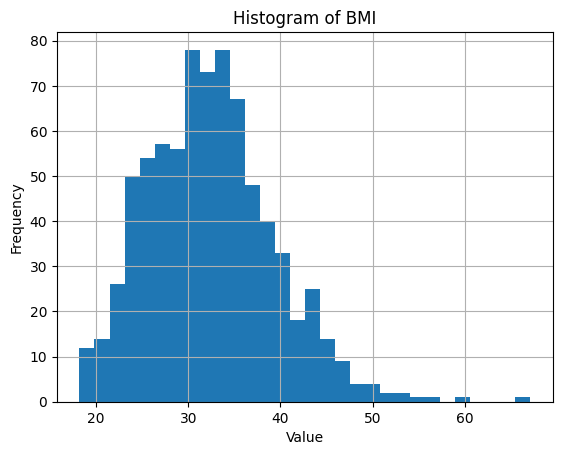

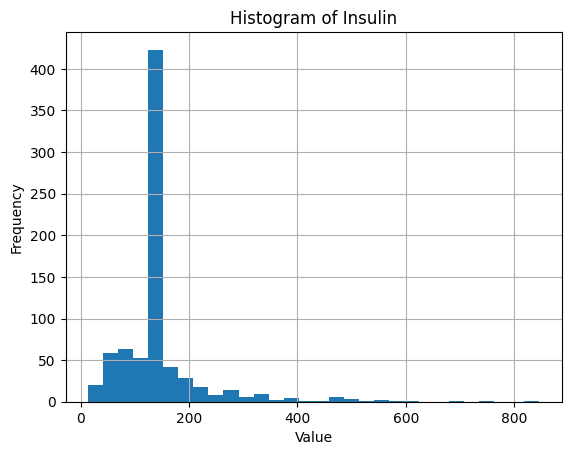

In [14]:
import matplotlib.pyplot as plt


variables = ('BMI', 'Insulin')

for v in variables:
  data[v].hist(bins=30)
  plt.title(f"Histogram of {v}")
  plt.xlabel("Value")
  plt.ylabel("Frequency")
  plt.show()

## Задание 11

Постройте круговую диаграмму для признака __Class__.

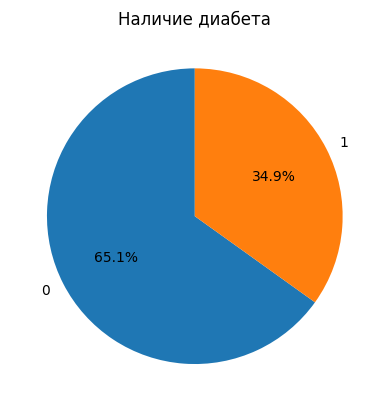

In [60]:
plt.figure()
plt.pie(
    data['Class'].value_counts(),
    labels=(0, 1),
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Наличие диабета')
plt.show()


## Задание 12



```
# This is formatted as code
```

Постройте распределение для признака __BMI__ и сравните его с нормальным (напишите вывод в новой markdown-ячейке под графиками)

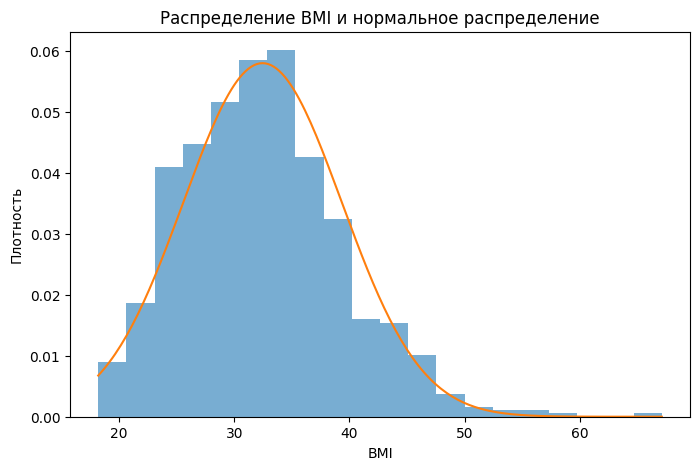

In [62]:
from scipy.stats import norm
import numpy as np

bmi = data['BMI'].dropna()

mu = bmi.mean()
sigma = bmi.std()

plt.figure(figsize=(8, 5))

plt.hist(bmi, bins=20, density=True, alpha=0.6)

x = np.linspace(bmi.min(), bmi.max(), 200)
y = norm.pdf(x, mu, sigma)
plt.plot(x, y)

plt.title('Распределение BMI и нормальное распределение')
plt.xlabel('BMI')
plt.ylabel('Плотность')
plt.show()

Распеределение не является нормальным, кривая асимметрична, с наклоном вправо, основные значения сконцетрированы в центральной части что и делает кривую не "нормальной"



## Задание 13

Постройте следующий график: процент больных диабетом в зависимости от числа беременностей.

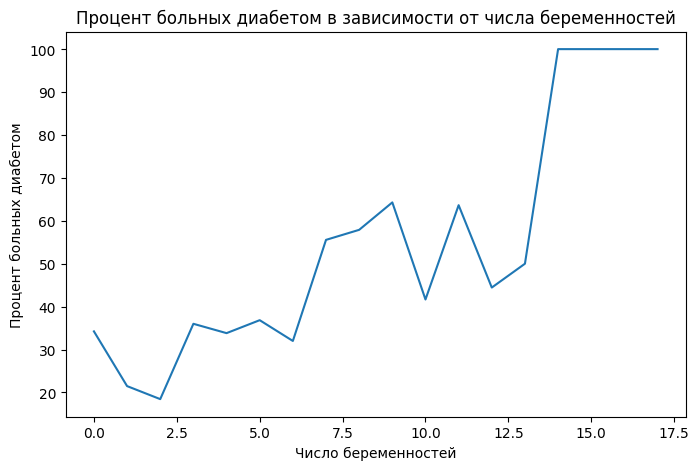

In [64]:
diabetes_percent = (
    data
    .groupby('Pregnancies')['Class']
    .mean() * 100
)

plt.figure(figsize=(8, 5))
plt.plot(
    diabetes_percent.index,
    diabetes_percent.values,
)
plt.xlabel('Число беременностей')
plt.ylabel('Процент больных диабетом')
plt.title('Процент больных диабетом в зависимости от числа беременностей')
plt.show()

## Задание 14

Добавьте новый бинарный признак:

__wasPregnant__ $\in$ {0,1} - была женщина беременна (1) или нет (0)

In [66]:
data['wasPregnant'] = data['Pregnancies'].apply(lambda x: 1 if x > 0 else 0)

## Задание 15

Сравните процент больных диабетом среди женщин, которые были беременны и не были.

In [67]:
diabetes_percent = (
    data
    .groupby('wasPregnant')['Class']
    .mean() * 100
)

print(diabetes_percent)

wasPregnant
0    34.234234
1    35.007610
Name: Class, dtype: float64


## Задание 16

Добавьте новый категориальный признак __bodyType__ на основе столбца BMI:

__BMI Categories:__
    
Underweight = <18.5

Normal weight = 18.5–24.9

Overweight = 25–29.9

Obesity = BMI of 30 or greater

Признак должен принимать значения Underweight, Normal weight, Overweight и Obesity.

In [69]:
bins = (-float('inf'), 18.5, 25, 30, float('inf'))
labels = ('Underweight', 'Normal weight', 'Overweight', 'Obesity')

data['bodyType'] = pd.cut(
    data['BMI'],
    bins=bins,
    labels=labels,
    right=False
)
data['bodyType']


,bodyType
0,Obesity
1,Overweight
2,Normal weight
3,Overweight
4,Obesity
...,...
763,Obesity
764,Obesity
765,Overweight
766,Obesity


## Задание 17

Будем считать "здоровыми" тех, у кого нормальный вес и кровяное давление. Какой процент "здоровых" женщин больны диабетом?

In [71]:
healthy = data[
    (data['bodyType'] == 'Normal weight') &
    (data['BloodPressure'] >= 80) &
    (data['BloodPressure'] <= 89)
]

percent_diabetes = healthy['Class'].mean() * 100
percent_diabetes

np.float64(10.0)

# Часть II

Каждое задание в этой части оценивается в 1,15 баллов. Всего за выполнение этой части можно получить 3,45 балла.

In [23]:
babies = pd.read_csv(BABIES, index_col=0)
babies.head(10)

,name,sex,number,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
5,Margaret,F,1578,1880
6,Ida,F,1472,1880
7,Alice,F,1414,1880
8,Bertha,F,1320,1880
9,Sarah,F,1288,1880


## Задание 1

Исследуйте набор данных `babies`. Ответьте на вопросы.

1. Какие годы включает датасет

2. Какое имя в датасете находится по индексом 121?

3. Cколько всего родилось детей по имени 'Aaron' за все время?

4. Насколько больше за все время родилось мальчиков чем девочек?

5. Cколько мальчиков родилось в 2010?

6. Сколько в датасете девочек по имени John?

In [75]:
print("1", babies['year'].min(), babies['year'].max(), "\n\n")

print("2", babies.loc[121, 'name'], "\n\n")

print("3", babies[babies['name'] == 'Aaron']['number'].sum())

boys = babies[babies['sex'] == 'M']['number'].sum()
girls = babies[babies['sex'] == 'F']['number'].sum()

print("4", boys - girls)


print("5", babies[
    (babies['year'] == 2010) &
    (babies['sex'] == 'M')
]['number'].sum())

print("6", babies[
    (babies['name'] == 'John') &
    (babies['sex'] == 'F')
]['number'].sum())



1 1880 2010 


2 121       Ann
121      Anne
121     Josie
121      Lola
121     Hazel
        ...  
121       Eva
121     Naomi
121     Bella
121     Jenna
121    Nicole
Name: name, Length: 131, dtype: object 


3 527668
4 2422447
5 1898382
6 21578


## Задание 2

1. Сгруппируйте набор данных babies по году и полу и сохраните результаты в два новых датафрейма: baby_girls и baby_boys.

2. Создайте фигуру matplotlib с 3 графиками один под другим.

3. Постройте линейные графики. Первый график должен показывать тренд рождаемости для девочек, второй - для мальчиков, третий объединять их все вместе (с теми же цветами, что в индивидуальных графиках). Годы - x, количество детей - y.

4. Верхняя и правая границы графиков должны быть невидимы, к каждому графику должен быть заголовок, третий график должен содержать легенду, шкалы графиков должны быть подписаны.

5. Для шкалы количество должны быть установлены лимиты, чтобы она была одинакова на обоих графиках.

6. Кратко опишите тренды в ячейке markdown под графиками.

Если при группировке вы сделали год индексом, то можно обратиться к значениям этой переменной через аттрибут `.index`

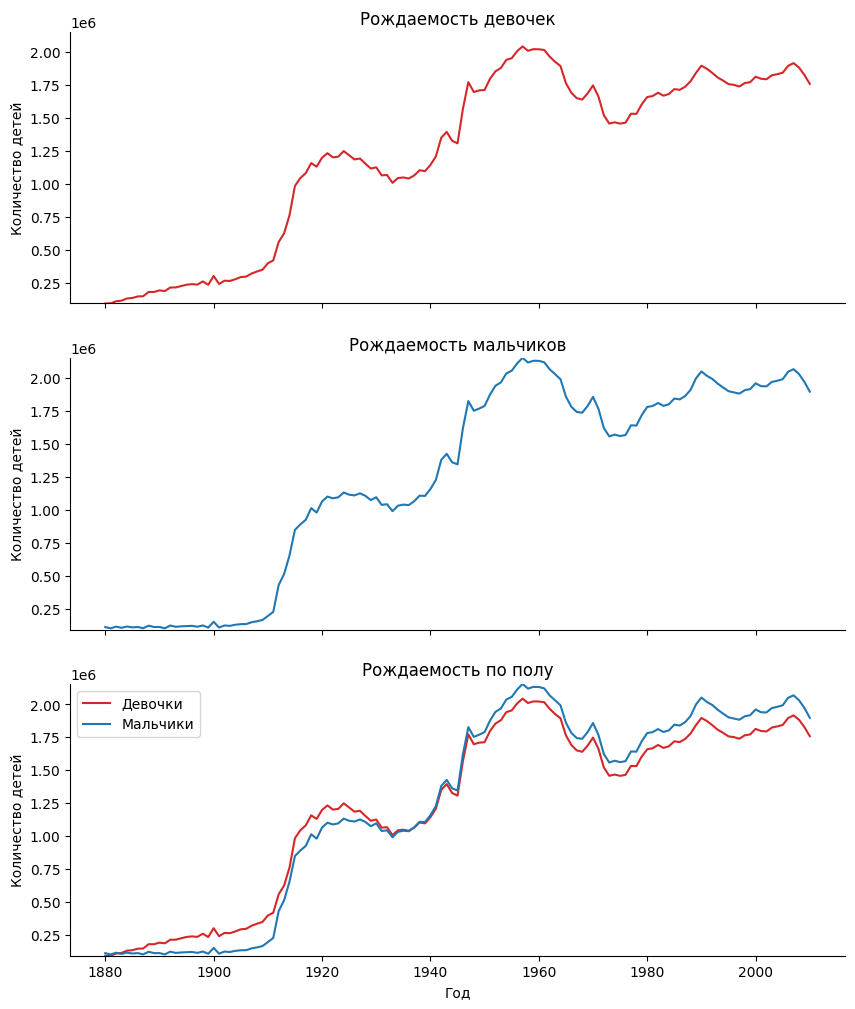

In [77]:
#1
grouped = (
    babies
    .groupby(['year', 'sex'])['number']
    .sum()
    .reset_index()
)

baby_girls = grouped[grouped['sex'] == 'F'].set_index('year')
baby_boys = grouped[grouped['sex'] == 'M'].set_index('year')

#2
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

#3
y_min = min(baby_girls['number'].min(), baby_boys['number'].min())
y_max = max(baby_girls['number'].max(), baby_boys['number'].max())

#4

#girls
axes[0].plot(
    baby_girls.index,
    baby_girls['number'],
    color='tab:red'
)
axes[0].set_title('Рождаемость девочек')
axes[0].set_ylabel('Количество детей')
axes[0].set_ylim(y_min, y_max)

#boys
axes[1].plot(
    baby_boys.index,
    baby_boys['number'],
    color='tab:blue'
)
axes[1].set_title('Рождаемость мальчиков')
axes[1].set_ylabel('Количество детей')
axes[1].set_ylim(y_min, y_max)

#both
axes[2].plot(
    baby_girls.index,
    baby_girls['number'],
    color='tab:red',
    label='Девочки'
)
axes[2].plot(
    baby_boys.index,
    baby_boys['number'],
    color='tab:blue',
    label='Мальчики'
)

axes[2].set_title('Рождаемость по полу')
axes[2].set_xlabel('Год')
axes[2].set_ylabel('Количество детей')
axes[2].set_ylim(y_min, y_max)
axes[2].legend()

#5
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

В течение рассматриваемого периода наблюдаются периоды роста и спада,
при этом число рождённых мальчиков стабильно немного превышает число девочек.
Общие изменения рождаемости во времени затрагивают оба пола практически синхронно,
что указывает на влияние общих социально-демографических факторов.

## Задание 3

1. Сгруппируйте нужным способом датафрейм babies и найдите 4 самых популярных имени за всю историю (2 женских и 2 мужских).

2. Для каждого найденного имени создайте новый датафрейм вида babies_alisa и сохраните в него данные, сколько детей с таким именем рождалось каждый год.

3. Создайте фигуру matplotlib с 4 горизонтальными графиками один под другим.

4. Постройте 4 линейных графика - тренд для каждого имени за все время.

5. Каждый график должен содержать легенду, один общий заголовок, шкалы графиков должны быть подписаны.

6. Для шкалы количество должны быть установлены лимиты, чтобы она была одинакова на обоих графиках.

7. Опишите тренды в ячейке markdown под графиками.

In [78]:
# суммарное количество рождений по имени и полу
name_totals = (
    babies
    .groupby(['name', 'sex'])['number']
    .sum()
    .reset_index()
)

# топ-2 женских имён
top_female = (
    name_totals[name_totals['sex'] == 'F']
    .sort_values('number', ascending=False)
    .head(2)
)

# топ-2 мужских имён
top_male = (
    name_totals[name_totals['sex'] == 'M']
    .sort_values('number', ascending=False)
    .head(2)
)

top_names = pd.concat([top_female, top_male])
top_names


,name,sex,number
61634,Mary,F,4103935
71051,Patricia,F,1568742
38999,James,M,5049727
43381,John,M,5040319


In [79]:
name_dfs = {}

for _, row in top_names.iterrows():
    name = row['name']
    sex = row['sex']

    df_name = (
        babies[
            (babies['name'] == name) &
            (babies['sex'] == sex)
        ]
        .groupby('year')['number']
        .sum()
    )

    name_dfs[name] = df_name


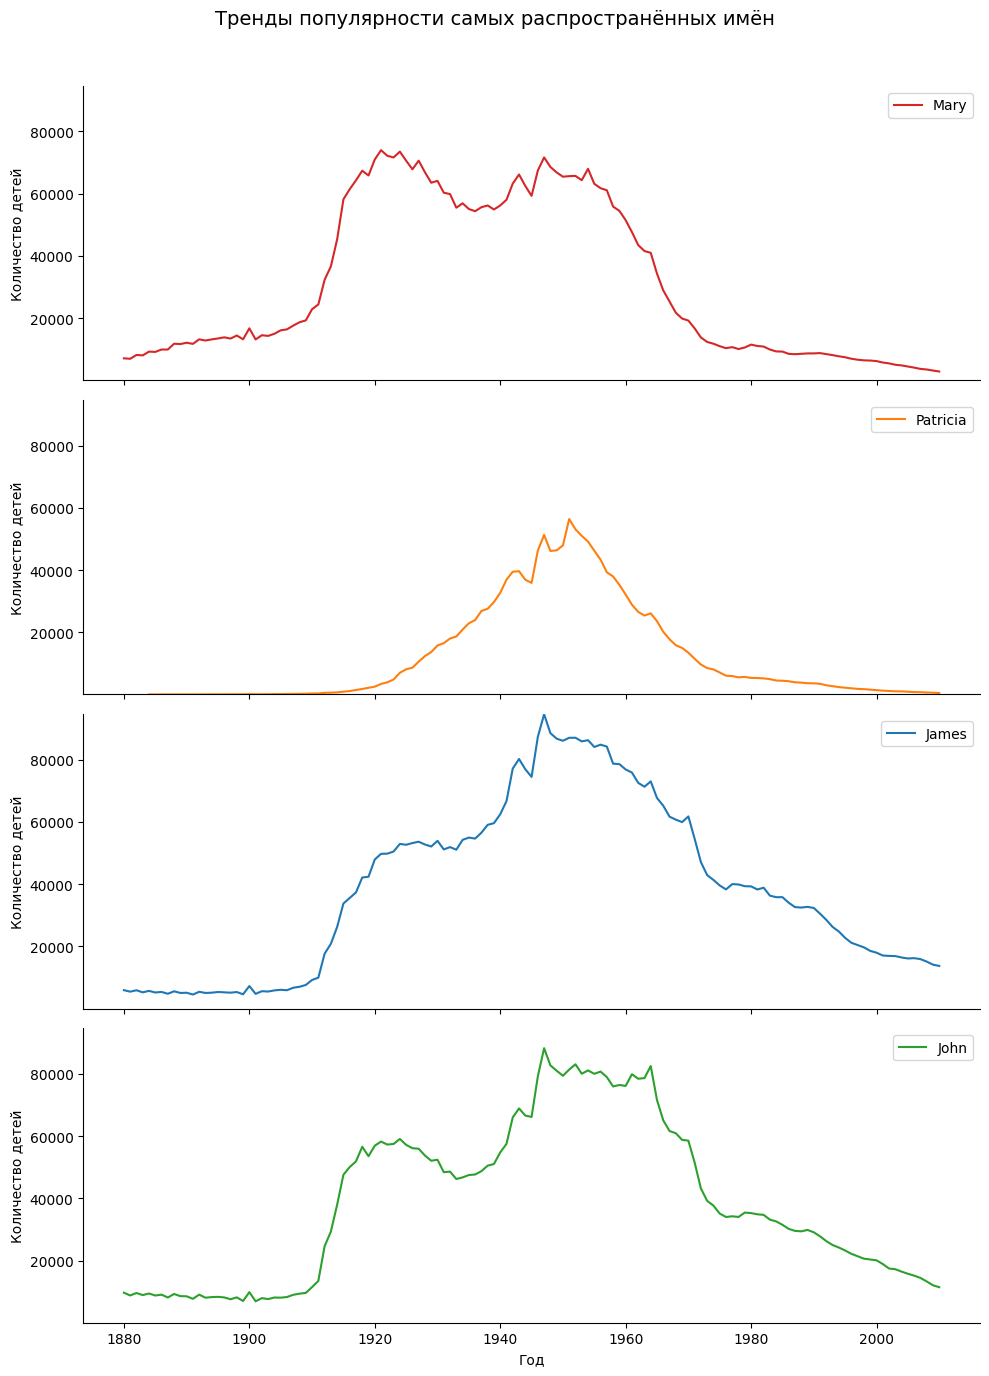

In [81]:
y_min = min(df.min() for df in name_dfs.values())
y_max = max(df.max() for df in name_dfs.values())

fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)
colors = ['tab:red', 'tab:orange', 'tab:blue', 'tab:green']

for ax, (name, series), color in zip(axes, name_dfs.items(), colors):
    ax.plot(series.index, series.values, color=color, label=name)
    ax.set_ylabel('Количество детей')
    ax.set_ylim(y_min, y_max)
    ax.legend()

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Год')
fig.suptitle('Тренды популярности самых распространённых имён', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Некоторые имена были особенно популярны в конце XIX – начале XX века,
после чего их использование постепенно снижалось.
Другие имена, напротив, сохраняют устойчивую популярность на протяжении
длительного периода или демонстрируют повторные волны роста.
В целом, тренды отражают изменения культурных и социальных предпочтений
в выборе имён в разные исторические периоды.

## Часть III

Каждое задание в этой части оценивается в 0,2 балла. Всего за выполнение этой части можно получить 4 балла.

Вам предлагается проанализировать датасет с Data - вакансиями.  
Скачайте его https://disk.yandex.ru/d/QUa3pCKVk48cAQ и считайте с помощью `pd.read_csv`.




In [90]:
df = pd.read_csv("vacancies.csv")
df.head(10)

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[]
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[]
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe..."
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[]
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']"
5,5,Data Scientist,China Good Car,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Дата-сайентист,"{'from': 450000, 'to': 'null', 'currency': 'KZ...",<strong>Обязанности:</strong> <p>- Проектирова...,"['Python', 'Обработка естественного языка (NLP..."
6,6,Стажер Data Scientist,WILDBERRIES,Москва,Нет опыта,Полный день,Стажировка,Дата-сайентист,NaN,<p>Начни свою карьеру в Wildberries!</p> <p>Мы...,[]
7,7,Стажер - Data Scientist,Эр-1,Пермь,Нет опыта,Удаленная работа,Стажировка,Дата-сайентист,NaN,<p><strong>R1</strong> — это новый взгляд на п...,[]
8,8,Аналитик данных/ data analyst,Skillzania,Москва,От 1 года до 3 лет,Удаленная работа,Полная занятость,"BI-аналитик, аналитик данных","{'from': 80000, 'to': 'null', 'currency': 'RUR...",<p><strong>Группа компаний SKILLZANIA это:<br ...,[]
9,9,Аналитик данных/ Data analyst,Bereke Bank,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Обязанности:</strong> <ul> <li>Поддерж...,[]


1. Выведите первые 5 и последние 5 строк датасета. Примените к датасету методы `info` и `describe`. Сколько в датасете строк и столбцов?

In [92]:
# первые 5
df.head(5)

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[]
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[]
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe..."
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[]
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']"


In [93]:
# последние 5
df.tail(5)

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
1522,1522,Senior Data Scientist в b2c направление,HeadHunter,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p>Наша команда работает с соискательской функ...,"['Python', 'Machine Learning', 'SQL', 'PyTorch..."
1523,1523,Data analyst (Senior),Иви,Москва,От 3 до 6 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>Иви — один из лидеров рынка онлайн-...,[]
1524,1524,Senior Data Analyst,Autodoc Group (Автодок Казахстан),Алматы,От 3 до 6 лет,Полный день,Полная занятость,Продуктовый аналитик,NaN,<p>Company Description</p> <p>AUTODOC is a tec...,[]
1525,1525,TeamLead Data Engineer,HeadHunter,Москва,От 3 до 6 лет,Полный день,Полная занятость,"Программист, разработчик",NaN,"<p><strong>Привет,</strong> <strong>на связи к...","['Python', 'Apache Airflow', 'Apache Cassandra..."
1526,1526,Senior Python Developer (Data Platform),Mindbox,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p><strong>Mindbox</strong> — крупнейшая в Рос...,"['Python', 'PySpark', 'Airflow', 'Kafka', 'Del..."


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1527 entries, 0 to 1526
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          1527 non-null   int64 
 1   position_name       1527 non-null   object
 2   employer_name       1527 non-null   object
 3   area                1527 non-null   object
 4   experience          1527 non-null   object
 5   schedule            1527 non-null   object
 6   employment          1527 non-null   object
 7   professional_roles  1527 non-null   object
 8   salary              220 non-null    object
 9   description         1527 non-null   object
 10  key_skills          1527 non-null   object
dtypes: int64(1), object(10)
memory usage: 131.4+ KB


In [95]:
df.describe()

,Unnamed: 0
count,1527.000000
mean,763.000000
std,440.951244
min,0.000000
25%,381.500000
50%,763.000000
75%,1144.500000
max,1526.000000


2. Есть ли в датасете пропуски?

In [96]:
df.isna().sum()

,0
Unnamed: 0,0
position_name,0
employer_name,0
area,0
experience,0
schedule,0
employment,0
professional_roles,0
salary,1307
description,0


3. Есть в датасете полные дубли? Если да, удалите их (метод drop_duplicates).

In [101]:
duplicates_count = df.duplicated().sum()
duplicates_count

if duplicates_count:
  df = df.drop_duplicates()

4. Сколько уникальных значений у переменной professional_roles?

In [102]:
df['professional_roles'].nunique()

36

5. Сколько в датасете вакансий, не требующих опыта?

In [32]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

6. Какое среднее количество навыков в вакансии? (переменная key_skills)

In [33]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

7. Какие валюты (ключ currency в поле salary) используются для заработной платы? Создайте столбец currency.  
*Подсказка. Как вариант, можете воспользоваться функцией eval, которая исполняет код, написанный в строке. Для проверки на NaN можете использовать pd.isnull()*

In [34]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

8. Какая компания лидирует по количеству вакансий?

In [35]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

9.  Какая компания лидирует по количеству вакансий с указанием заработной платы?

In [36]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

10. Создайте столбец salary_num. Рассчитайте его, используя столбец salary. Если в это столбце указана вилка зарплаты, используйте среднее значение между from и to. Если указано только одно из значений (from или to, используйте его) **(2)**

In [37]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

11. Какая средняя заработная плата среди вакансий в рублях? А медианная заработная плата?  

In [38]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

12. Создайте столбец is_python_requirement, который принимает значение 1, если в key_skills присутствует python (учитывайте написание в любом регистре, а также вхождения подстроки python.).  Какой процент вакансий требует знания python?

In [39]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

13. Сгруппируйте по столбцам experience, schedule, employment, is_python_requirement (сразу по четырем столбцам). Найдите по каждой группе:
- количество опубликованных вакансий
- количество компаний, которые опубликовали вакансии
- среднюю заработную плату среди вакансий с указанием зарплаты в рублях


In [40]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

14. Создайте столбец count_skills. В нём должна быть длина списка, который находит в столбце key_skills. Обратите внимание, что изначально столбец key_skills - строка, например, '[]' Подумайте, как превратить её в список и посчитать его длину.  

In [41]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

15. Создайте столбец len_descr, в котором должна быть длина описания (description) в символах без учета html тегов ("<...>"). Напишите для этого функцию get_len_descr.  Можете использовать регулярные выражения.
То есть, ваш код может выглядеть, например, так:

In [42]:
import re

def get_len_descr(descr):
  clean_descr = re.sub( # ваш код
  # ваш код
  return len_descr

df['len_descr'] = df['description'].apply(# ваш код)

SyntaxError: invalid syntax (ipython-input-525118681.py, line 6)

16. Постройте таблицу корреляций с тремя переменными: salary_num, len_descr, count_skills.  

In [ ]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

17. Постройте тепловую карту из таблицы из предыдущего пункта.

In [ ]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

18. Какие скиллы чаще всего требуются? Выведите топ-10 требуемых скиллов.

In [ ]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

19. Постройте гистограмму распределения зарплаты среди вакансий в рублях.  

In [ ]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

20. Постройте boxplot зарплаты (среди вакансий в рублях) с группировкой по полю experience

In [ ]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。